In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd

ddir = 'data/'

# df = pd.read_csv(os.path.join(ddir,'chembl_augmented_valid.csv'),usecols=['SMILES'])
# df.columns = ['smiles']

# from rdkit_utils import *

# df_med = df[df.smiles.str.len() >= 20]
# df_med = df_med[df.smiles.str.len() <= 30]
# df_med['smiles'] = df_med.smiles.apply(lambda x: get_cansmiles(x))
# df_med.drop_duplicates(inplace=True)
# print(len(df_med))

# df_samp = df_med.sample(10000, replace=False)
# df_samp.to_csv('data/df_samp_20to30_10000.csv',index=False)

df = pd.read_csv(os.path.join(ddir,'df_samp_20to30_10000.csv'))
df.head(5)

,smiles
0,COc1cccc2oc(=O)cc(N3CCOCC3)c12
1,CNCCCCNC1(c2cc3ccccc3s2)CCCCC1
2,NCC1OC2OCCC1(O)C2O
3,Cc1c(O)c(CN)c(Cl)c(C)c1Cl
4,CCCC1C2CNCC12c1ccc(Cl)c(Cl)c1


In [2]:
from rdkit.Chem import PandasTools
def displaydf(df):
    return HTML(df.to_html(notebook=True))

PandasTools.AddMoleculeColumnToFrame(df,'smiles','mol',includeFingerprints=False)

from data_utils import *
atom_to_cnt = get_atom_cnts(df.smiles)
# atom_to_cnt

In [3]:
from rdkit_utils import *
from graph_augs import *

from rdkit import RDLogger  
RDLogger.DisableLog('rdApp.*')

def get_augs(smiles,maximum=10):
    
    mol = Chem.MolFromSmiles(smiles)

    idc = [i for i in range(0,(mol.GetNumAtoms()))]
    random.shuffle(idc)
    
    goods = 0 
    aug_smiles = []
    for i in idc:
        if goods==maximum:
            break
            
        atom_type = get_weighted_random_atom(atom_to_cnt)
        
        try: 
            mol_aug = add_atom_to_mol(mol, atom_type, i, clean_aroms = False)
            if mol_aug.GetNumAtoms()==0:
                continue
            else:
                sm = Chem.MolToSmiles(mol_aug)
                goods+=1
                aug_smiles.append(sm)
        except Exception as e:
            continue
            
    return (smiles, aug_smiles)

In [4]:
from joblib import Parallel, delayed
import multiprocessing

parallelizer = Parallel(n_jobs=multiprocessing.cpu_count()-1, backend= 'multiprocessing' )
augs_tasks = (delayed(get_augs)(smiles) for smiles in df.smiles)
smiles_to_augs = parallelizer(augs_tasks)

smiles_to_augs = {k:v for k,v in smiles_to_augs}

In [5]:
# for k,v in smiles_to_augs.items():
#     print(k,len(v))

5
= = = = = = = =


'O=C1C(=O)C(Br)(Br)C(Br)=C1Br'

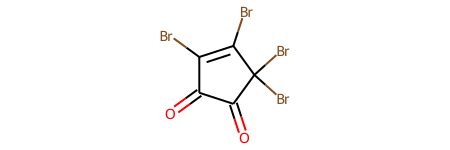

= = = = = = = =


'FC(F)(F)c1nnc(N=c2ssnc2Cl)s1'

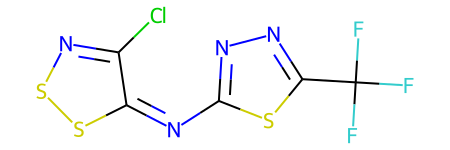

= = = = = = = =


'FC(Cl)(Cl)OC(F)(F)C(F)(F)Cl'

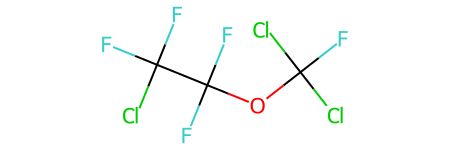

= = = = = = = =


'FC(F)(F)c1nc(Br)[nH]c1C(F)(F)F'

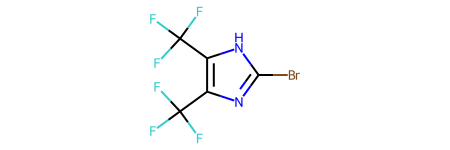

= = = = = = = =


'FC(F)(Cl)OC(F)(F)C(F)(Cl)Cl'

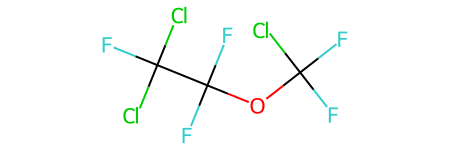

In [6]:
from rdkit_utils import *
from graph_augs import *

no_augs = [k for k,v in smiles_to_augs.items() if len(v)==0]
print(len(no_augs))

for smiles in no_augs:
    print('= = = = = = = =')
    mol = Chem.MolFromSmiles(smiles)
    
    mol_show = show_atom_index(mol)
    display(Chem.MolToSmiles(mol), mol)
    
    try:
        mol_new = add_atom_to_mol(mol,'C',3)
        display(mol_new)
    
    except:
        continue

'c1ccc2c(CCc3nnn[nH]3)c[nH]c2c1'

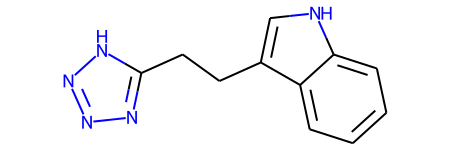

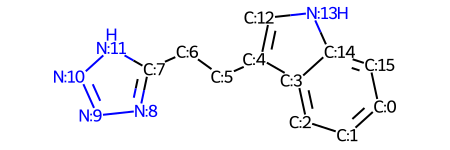

In [7]:
test = 'c1ccc2c(CCc3nnn[nH]3)c[nH]c2c1'
mol = Chem.MolFromSmiles(test)

mol_show = show_atom_index(mol)
display(Chem.MolToSmiles(mol), mol, mol_show)

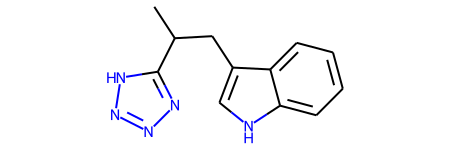

In [8]:
mol_new =  add_atom_to_mol(mol, 'C', 6, clean_aroms = False, clean_it = True)
mol_new

In [9]:
Chem.MolToSmiles(mol_new)

'CC(Cc1c[nH]c2ccccc12)c1nnn[nH]1'

In [10]:
Chem.MolFromSmiles('C(Cc1cnc2ccccc12)c1nnnn1')